# SHRED for ROMs: assessment of the physical consistency

This notebook checks the physical consistency of the SHRED reconstruction on the velocity field $\mathbf{u}$, by evaluating the incompressible continuity equation $\nabla\cdot\mathbf{u}=0$ on both the FOM and the SHRED prediction.

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

data_root = os.environ.get("NUSHRED_DATA_DIR", "../../NuSHRED_Datasets")
path_snaps = os.path.join(data_root, "MSFR/")
domain_plot = pickle.load(open(os.path.join(path_snaps, "domain.pkl"), "rb"))

import sys
sys.path.append('../P2/')

idx_params, params, var_names, is_vector, fom_times, rescaling_snaps, Nmodes = pickle.load(open(path_snaps+'msfr_p.uloff', 'rb'))
fom_times = np.array(fom_times)

path_svd = 'OfflineSVD/'
measure = 'outcore-random' # 'outcore-random', 'incore-random', 'outcore-eim
if measure == 'incore-random':
  measurements = pickle.load(open(path_svd+'measurements_incore.data', 'rb'))
elif measure == 'outcore-eim':
  measurements = pickle.load(open(path_svd+'measurements_EIM.data', 'rb'))
else:
  measurements = pickle.load(open(path_svd+'measurements_3.data', 'rb'))

In [2]:
Nvariables = len(var_names)
n_configurations = measurements['location'].shape[1]
num_sensors = measurements['noisy_output'].shape[0]

assert measurements['noisy_output'].shape[2] == n_configurations

Ns = measurements['noisy_output'].shape[1]

Let us define the tex variables

In [3]:
tex_var_names = [r'\mathbf{u}', 'T', r'\Phi']
energy_groups = 6
tex_var_names.extend([r'\phi_'+str(g+1) for g in range(energy_groups)])

prec_groups = 8
tex_var_names.extend([r'c_'+str(g+1) for g in range(prec_groups)])

tex_var_names.extend(['p', r'p_{\text{rgh}}', r'\kappa', r'\nu_t', "q'''"])

assert len(tex_var_names) == len(var_names)

Let us import the mesh (as a PyVista grid with real cell connectivity, used to compute the divergence of the velocity field)

In [15]:
import pyvista as pv
from IPython.display import clear_output

# Comment this line if you don't want to use the SSH connection
# pv.start_xvfb()

domain_grid = pv.read(os.path.join(path_snaps, "evol_domain.vtk"))
mesh_plot = domain_grid.points[:, [0, 2]]

measured_field = 0  # velocity 'U'
clear_output()

Let us define a helper to attach a snapshot (as a plain numpy array) to a copy of the PyVista grid, so that PyVista's cell-based operators (`compute_derivative`, `compute_cell_sizes`) can be used.

In [5]:
def vector_grid(values: np.ndarray, varname='u'):
    """Attach a flattened (Nh*3,) vector field to a copy of the mesh grid."""
    grid = domain_grid.copy()

    vec = np.zeros((grid.n_points, 3))
    vec[:, :] = values.reshape(grid.n_points, 3)
    grid[varname] = vec

    return grid

## Loading the SHRED ensemble

We reload the same trained SHRED ensemble used in `02a_shred_uq.ipynb` (out-core, 3 sensors) and reconstruct the mean prediction on the test set, following the same steps as `02a`.

In [6]:
from shred.processdata import TimeSeriesDataset
import shred.models as models
import torch
from sklearn.preprocessing import MinMaxScaler

if measure == 'incore-random':
    path_shred = './SHRED/InCore/'
elif measure == 'outcore-eim':
    path_shred = './SHRED/EIM/'
else:
    path_shred = './SHRED/'

v_total = pickle.load(open(path_svd+'v_total.svd', 'rb'))
Nmodes = [10 for i in range(Nvariables)]
assert sum(Nmodes) == v_total.shape[1]

lags = 52
_load_X = v_total.T
sensor_locations = np.arange(0, num_sensors, 1, dtype=int)

shred = list()
test_datasets = list()

# Reconstruction - splitting into train, test and validation (same seed as 02a)
np.random.seed(42)
train_indices = np.random.choice(Ns - lags, size=350, replace=False)
mask = np.ones(Ns - lags)
mask[train_indices] = 0
valid_test_indices = np.arange(0, Ns - lags)[np.where(mask!=0)[0]]
valid_indices = valid_test_indices[::2]
test_indices = valid_test_indices[1::2]

device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

for kk in range(n_configurations):

    Xsensor = measurements['noisy_output']
    load_X = np.hstack((Xsensor[:,:,kk].T, _load_X.T))

    m = load_X.shape[1]
    assert m == sum(Nmodes) + num_sensors

    shred.append(models.SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, decoder_sizes=[350, 400], dropout=0.1).to(device))

    sc = MinMaxScaler()
    sc = sc.fit(load_X[train_indices])

    if num_sensors != 3:
        shred[kk].load_state_dict(torch.load(path_shred+'trained_config'+str(kk)+'_measuring_'+str(num_sensors)+'sens_'+var_names[measurements['measured_field']]+'.shred'))
        test_datasets = pickle.load(open(path_shred+'datasets_measuring_'+str(num_sensors)+'.test', 'rb'))
    else:
        shred[kk].load_state_dict(torch.load(path_shred+'trained_config'+str(kk)+'_measuring_'+var_names[measurements['measured_field']]+'.shred'))
        test_datasets = pickle.load(open(path_shred+'datasets.test', 'rb'))

    shred[kk].freeze()

In [7]:
Ytest_POD_hat = torch.stack([shred[kk](test_datasets[kk]['X']) for kk in range(n_configurations)], dim=0)

Ytest_POD_pred = {
    'mean': Ytest_POD_hat.mean(axis=0),
    'std':  Ytest_POD_hat.std(axis=0) / np.sqrt(n_configurations),
}

reshaped_test_out = sc.inverse_transform(test_datasets[0]['Y'].detach().cpu().numpy())[:, num_sensors:]
reshaped_test_pred = {
    'mean': sc.inverse_transform(Ytest_POD_pred['mean'].detach().cpu().numpy())[:, num_sensors:],
    'std': (sc.inverse_transform(Ytest_POD_pred['std'].detach().cpu().numpy()) - sc.data_min_)[:, num_sensors:],
}

u_total = {
    field: pickle.load(open(os.path.join(path_snaps, f"CompressedDataset/pod_basis_{field}.svd"), "rb"))[:, :Nmodes[field_i]] for field_i, field in enumerate(var_names)
}
s_total = {
    field: np.diag(pickle.load(open(os.path.join(path_snaps, f"CompressedDataset/sing_vals_{field}.svd"), "rb")))[:Nmodes[field_i]] for field_i, field in enumerate(var_names)
}

Let us decode the mean POD coefficients (FOM ground truth and SHRED prediction) back to the full-order velocity field

In [8]:
field_i = measured_field  # velocity 'U'
field = var_names[field_i]

u_ = u_total[field]
s_ = np.diag(s_total[field])

v_truth = reshaped_test_out[:, sum(Nmodes[:field_i]) : sum(Nmodes[:field_i+1])]
v_mean  = reshaped_test_pred['mean'][:, sum(Nmodes[:field_i]) : sum(Nmodes[:field_i+1])]

fom = (u_ @ s_ @ v_truth.T)
prediction = (u_ @ s_ @ v_mean.T)

time_bins = fom_times[test_indices + lags]

## Check the continuity equation (Mass conservation)
The MSFR MP model considers the fluid to be incompressible: in the following, the divergence of the velocity is computed for both FOM and SHRED predictions to check the mass conservation.

The following cell computes $|\nabla\cdot \mathbf{u}|$ for both FOM and SHRED predictions at each point of the mesh and for all the times within the test set.

In [9]:
cont_eqn_fom   = np.asarray([np.abs(vector_grid(fom[:, tt]).compute_derivative(scalars='u', divergence=True)['divergence']) for tt in range(fom.shape[1])])
cont_eqn_shred = np.asarray([np.abs(vector_grid(prediction[:, tt]).compute_derivative(scalars='u', divergence=True)['divergence']) for tt in range(prediction.shape[1])])

Let us make a plot over time of the divergence of the velocity field for both FOM and SHRED predictions.

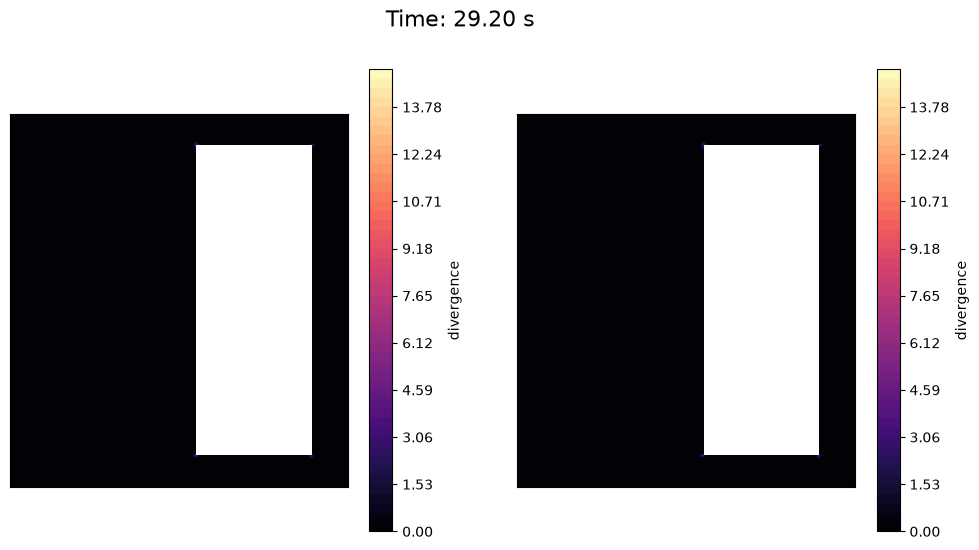

In [17]:
from plots import get_core_msfr_geometry
from IPython.display import clear_output as clc

levels = np.linspace(0, 15, 50)

for tt in range(5, fom.shape[1], 5):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    cont = axs[0].tricontourf(mesh_plot[:, 0], mesh_plot[:, 1], (cont_eqn_fom[tt]), levels=levels, cmap=cm.magma)
    fig.colorbar(cont, ax=axs[0], label='divergence')
    get_core_msfr_geometry(axs[0])

    cont = axs[1].tricontourf(mesh_plot[:, 0], mesh_plot[:, 1], (cont_eqn_shred[tt]), levels=levels, cmap=cm.magma)
    fig.colorbar(cont, ax=axs[1], label='divergence')
    get_core_msfr_geometry(axs[1])

    fig.suptitle(f'Time: {time_bins[tt]:.2f} s', fontsize=16)

    plt.show()
    clc(wait=True)
    plt.close()

However, the OpenFOAM solver solves for the continuity imposing a local balance, i.e. for any cell $\Omega_i$ of mesh 
$$ 
\int_{\Omega_i} \nabla\cdot \mathbf{u} \, d\Omega_i = 0 
$$

Below we are going to compute and store this for each cell of the mesh and for each time step.

In [ ]:
cont_eqn_fom_cell = list()
cont_eqn_shred_cell = list()

for tt in range(fom.shape[1]):
    # FOM
    grid = vector_grid(fom[:, tt])
    grid['div'] = grid.compute_derivative(scalars='u', divergence=True)['divergence']
    cells_size = grid.compute_cell_sizes()['Volume']
    cont_eqn_fom_cell.append(cells_size * grid.point_data_to_cell_data()['div'])

    # SHRED
    grid = vector_grid(prediction[:, tt])
    grid['div'] = grid.compute_derivative(scalars='u', divergence=True)['divergence']
    cells_size = grid.compute_cell_sizes()['Volume']
    cont_eqn_shred_cell.append(cells_size * grid.point_data_to_cell_data()['div'])

cont_eqn_fom_cell = np.asarray(cont_eqn_fom_cell)
cont_eqn_shred_cell = np.asarray(cont_eqn_shred_cell)

Let us average this value over time and plot the histogram of the divergence of the velocity field for both FOM and SHRED predictions.

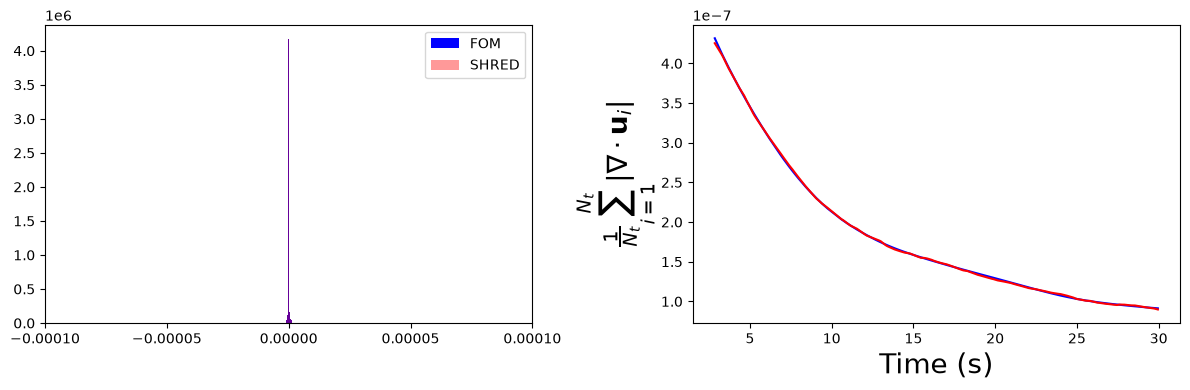

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(cont_eqn_fom_cell.mean(axis=0), bins=500, density=True, color='blue', label='FOM')
axs[0].hist(cont_eqn_shred_cell.mean(axis=0), bins=500, density=True, alpha=0.4, color='red', label='SHRED')
axs[0].set_xticks(np.arange(-1e-4, 1.1e-4, 5e-5))
axs[0].legend()

axs[1].plot(time_bins, np.mean(np.abs(cont_eqn_fom_cell), axis=1), label='FOM', color='blue')
axs[1].plot(time_bins, np.mean(np.abs(cont_eqn_shred_cell), axis=1), label='SHRED', color='red')
axs[1].set_xlabel('Time (s)', fontsize=20)
axs[1].set_ylabel(r'$\frac{1}{N_t}\sum_{i=1}^{N_t}|\nabla \cdot \mathbf{u}_i|$', fontsize=20)

plt.tight_layout()